# Phishing detection using multiple CNN architectures

In this notebook I will investigate the detection of phishing websites. This is based on an extensive dataset of website information like: 
- page_rank
- url_length
- favicon presence
- domain age

This dataset contains 2500 website examples from the [Phishtank](https://www.phishtank.com/) archive, a website responsible for cataloging phishing websites. The [article](https://eprints.hud.ac.uk/id/eprint/16229/1/he_7th_ICITST_2012_Conference_-An_Assessment_of_Features_Related_to_Phishing_Websites_using_an_Automated_Technique.pdf) accompanying the dataset aims to create a comprehensive dataset with features that have been proven to be relevant for detecting phishing websites.

The dataset only contains values as [-1, 0, 1] (mapping to [legitimate, suspicious, phishing]) and is built with a rule-based engine. This significantly reduces the complexity of the source data and is a form of feature selection.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
phishing_websites = fetch_ucirepo(id=327) 
  
X = phishing_websites.data.features 
y = phishing_websites.data.targets 
  
display(phishing_websites.metadata)

{'uci_id': 327,
 'name': 'Phishing Websites',
 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites',
 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv',
 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.',
 'area': 'Computer Science',
 'tasks': ['Classification'],
 'characteristics': ['Tabular'],
 'num_instances': 11055,
 'num_features': 30,
 'feature_types': ['Integer'],
 'demographics': [],
 'target_col': ['result'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2012,
 'last_updated': 'Tue Mar 05 2024',
 'dataset_doi': '10.24432/C51W2X',
 'creators': ['Rami Mohammad', 'Lee McCluskey'],
 'intro_paper': {'ID': 396,
  'type': 'NATIVE',
  'title': 'An assessment of features related to phishing websites using an automated technique',
  'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey',
  'venue': 'International

In [2]:
print(phishing_websites.variables.name) 

0              having_ip_address
1                     url_length
2             shortining_service
3               having_at_symbol
4       double_slash_redirecting
5                  prefix_suffix
6              having_sub_domain
7                 sslfinal_state
8     domain_registration_length
9                        favicon
10                          port
11                   https_token
12                   request_url
13                 url_of_anchor
14                 links_in_tags
15                           sfh
16           submitting_to_email
17                  abnormal_url
18                      redirect
19                  on_mouseover
20                    rightclick
21                   popupwindow
22                        iframe
23                 age_of_domain
24                     dnsrecord
25                   web_traffic
26                     page_rank
27                  google_index
28        links_pointing_to_page
29            statistical_report
30        

There we have a nice overview of the data. Let's now inspect how the variables are encoded. Most of the variables are encoded such that there are two options: `[non-phishing, phishing]`, but in some cases there is a third option `suspicious`. The binary classes we can use as is, but the classes with three options need to be one-hot-encoded. For this we will first add 1 to every entry in the dataset such that all entries are non-negative integers.

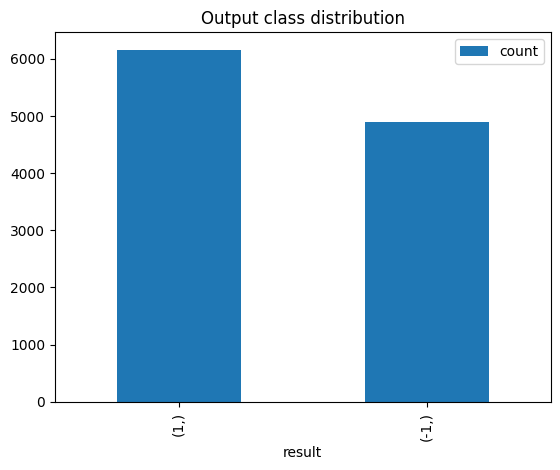

In [ ]:
import matplotlib.pyplot as plt
y.value_counts().plot.bar()
plt.title("Output class distribution")
plt.legend()

In [3]:
(X.nunique() > 2).sum()

np.int64(8)

In [4]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd 

binary_columns = X.columns[X.nunique() == 2]
ternary_columns = X.columns.drop(binary_columns)

X_scaled = X.copy()
X_scaled[binary_columns] = (X_scaled[binary_columns] + 1) // 2
X_scaled[ternary_columns] = X_scaled[ternary_columns] + 1

encoder = OneHotEncoder(
    sparse_output=False
)

encoded = encoder.fit_transform(X_scaled[ternary_columns])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(),
    dtype=int
)

X_one_hot = pd.concat([X_scaled[binary_columns], encoded_df], axis=1) # Shape(11055, 46)
X_one_hot.describe()

,having_ip_address,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,domain_registration_length,favicon,port,https_token,request_url,...,links_in_tags_2,sfh_0,sfh_1,sfh_2,web_traffic_0,web_traffic_1,web_traffic_2,links_pointing_to_page_0,links_pointing_to_page_1,links_pointing_to_page_2
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.656897,0.869380,0.850294,0.870737,0.132519,0.331615,0.814292,0.864134,0.837540,0.593397,...,0.239711,0.763455,0.068838,0.167707,0.240163,0.232384,0.527454,0.049570,0.556852,0.393578
std,0.474767,0.336999,0.356799,0.335506,0.339070,0.470815,0.388888,0.342662,0.368889,0.491222,...,0.426926,0.424979,0.253189,0.373623,0.427202,0.422371,0.499268,0.217065,0.496780,0.488565
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

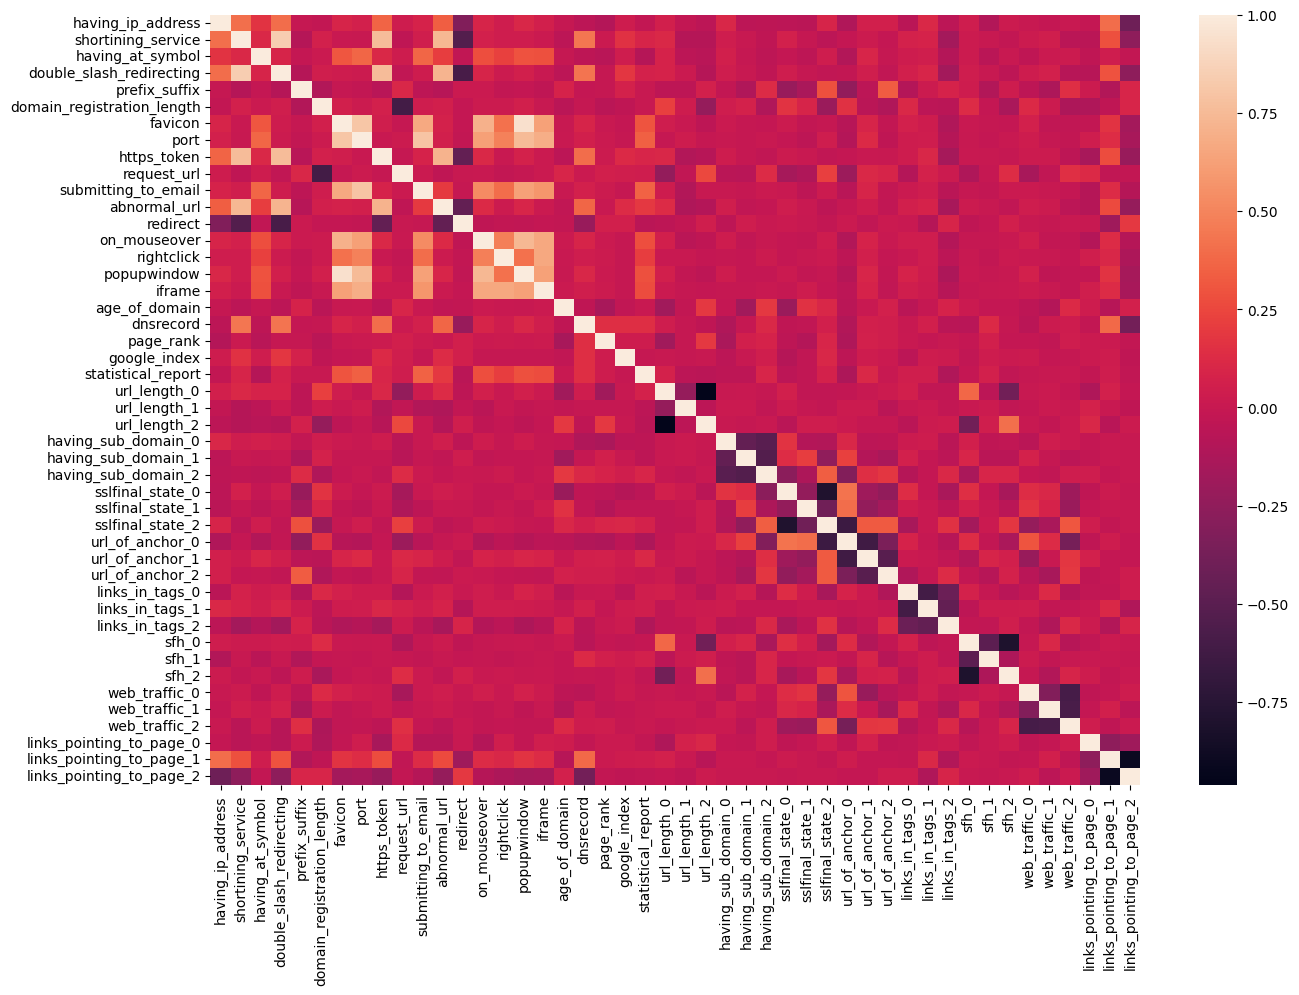

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(X_one_hot.corr())

In [6]:
import numpy as np

corr_matrix = X_one_hot.corr()
upper_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))
correlations = upper_corr.stack().reset_index()
correlations.columns = ['var_1', 'var_2', 'correlation']
filtered_correlations = correlations[abs(correlations['correlation']) > 0.7]
filtered_correlations.sort_values(by="correlation", ascending=False).reset_index(drop=True)

,var_1,var_2,correlation
0,favicon,popupwindow,0.939633
1,shortining_service,double_slash_redirecting,0.842796
2,favicon,port,0.803834
3,port,submitting_to_email,0.799088
4,double_slash_redirecting,https_token,0.760799
5,shortining_service,https_token,0.757838
6,port,popupwindow,0.748517
7,shortining_service,abnormal_url,0.739290
8,on_mouseover,popupwindow,0.733629
9,double_slash_redirecting,abnormal_url,0.723724


There are significant correlations within the dataset. Specifically, the favicon/popupwindow correlation is very high. 

Since I want to keep interpretability as high as possible (which is already challenging in NN architectures), I will not perform dimensionality reduction. Event hough, as you can see below, we need only 27/46 of the dataset to explain most of the variance. The first iteration of the model will be with all data to provide insight.

In [7]:
from sklearn.decomposition import PCA
import numpy as np

THRESHOLD = 0.95
pca = PCA()
pca.fit(X_one_hot, y)
k = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), THRESHOLD)
f"To keep {THRESHOLD*100}% of the variance, we need to keep {k+1}/{len(X_one_hot.columns)} components."

'To keep 95.0% of the variance, we need to keep 27/46 components.'

In [8]:
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_one_hot, y)

We do need to set up a test/train/validation split first before we start training the model.

In [9]:
from sklearn.model_selection import train_test_split

def split_data(X, y, rs=42, tt_split=0.6, tv_split=0.5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=tt_split, random_state=rs, stratify=y)
    X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=tv_split, random_state=rs, stratify=y_test)
    return X_train, X_test, X_val, y_train, y_test, y_val

X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y)

print(
    "X", X_one_hot.shape,
    "X_train", X_train.shape,
    "X_test", X_test.shape,
    "X_val", X_val.shape
)

X (11055, 46) X_train (6633, 46) X_test (2211, 46) X_val (2211, 46)


## Getting a baseline

The first step is to take the data and feed it into a simple linear regression model to establish baseline performance.

In [56]:
from sklearn.linear_model import LogisticRegression

lr_baseline = LogisticRegression()
lr_baseline.fit(X_train, y_train.to_numpy().reshape(-1))
lr_baseline_score = lr_baseline.score(X_test, y_test.to_numpy().reshape(-1))
lr_baseline_score

0.9357756671189507

Just for comparison, let's take the reduced dimensionality representation and see if it matters.

In [57]:
X_train_red, X_test_red, X_val_red, y_train_red, y_test_red, y_val_red = split_data(X_reduced, y)

lr_reduced_baseline = LogisticRegression()
lr_reduced_baseline.fit(X_train_red, y_train.to_numpy().reshape(-1))
lr_baseline_reduced_score = lr_reduced_baseline.score(X_test_red, y_test.to_numpy().reshape(-1))
lr_baseline_reduced_score

0.9344188150158299

At this stage there is no difference in performance, so no reason to keep the dimensionality reduced. Only when we run into compute issues later on we might consider this.

Let's also try with a more sophisticated model, a RandomForestClassifier.

accuracy is 0.970
roc-auc is 0.996


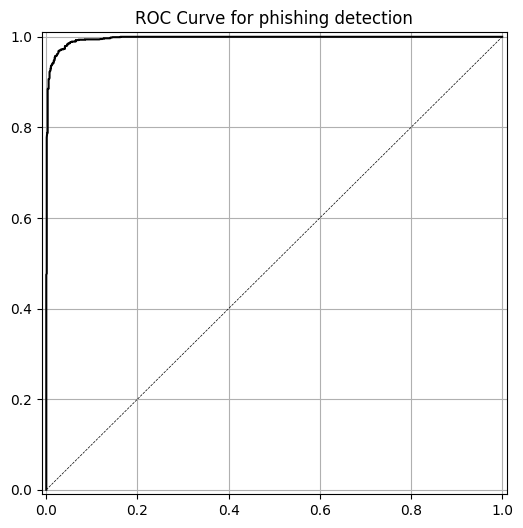

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train.values.ravel())

# Get class prediction for each sample
y_pred_class_rf = rf_model.predict(X_test)
# Get probability for each class for each sample
y_pred_prob_rf = rf_model.predict_proba(X_test)

rf_baseline_score = accuracy_score(y_test, y_pred_class_rf)

print(f'accuracy is {rf_baseline_score:.3f}')
print(f'roc-auc is {roc_auc_score(y_test, y_pred_prob_rf[:,1]):.3f}')

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_rf[:, 1])
_, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, 'k-')
ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)
ax.grid(True)
ax.set(title='ROC Curve for phishing detection',
        xlim=[-0.01, 1.01], ylim=[-0.01, 1.01]);

And let's also try with the dimensionality reduced version

In [63]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train_red, y_train.values.ravel())

# Get class prediction for each sample
y_pred_class_rf = rf_model.predict(X_test_red)

rf_baseline_reduced_score = accuracy_score(y_test, y_pred_class_rf)
rf_baseline_reduced_score

0.9647218453188603

Finally, let's take an SVM with an RBF kernel.

In [64]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf')
svc_model.fit(X_train, y_train)
svc_baseline_score = svc_model.score(X_test, y_test)

svc_model = SVC(kernel='rbf')
svc_model.fit(X_train_red, y_train)
svc_baseline_reduced_score = svc_model.score(X_test_red, y_test)

svc_baseline_score, svc_baseline_reduced_score

c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(0.9547715965626413, 0.9552238805970149)

The baseline performance of this model is *much* stronger, even getting to a 96% accuracy and a very strong ROC/AUC curve. Let's see if we can get better performance with a Neural Network.

Now we can take this and make a nice overview.

In [68]:
baseline_data =  {
    "LogisticRegression": {
        "full": lr_baseline_score,
        "reduced": lr_baseline_reduced_score,
    },
    "RandomForest": {
        "full": rf_baseline_score,
        "reduced": rf_baseline_reduced_score,
    },
    "SVM": {
        "full": svc_baseline_score,
        "reduced": svc_baseline_reduced_score,
    }
}

baseline_df = pd.DataFrame(baseline_data)
baseline_df

,LogisticRegression,RandomForest,SVM
full,0.935776,0.965626,0.954772
reduced,0.934419,0.964722,0.955224


Next, let's build a simple Neural Network that can predict whether a website is a phishing website or not.

## Building the model

We start with a simple model of a single layer input layer, a single hidden layer and a single output layer.

In [69]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.utils import plot_model

INPUT_SIZE = X_one_hot.shape[1]
HIDDEN_SIZE = INPUT_SIZE // 2
OUTPUT_SIZE = 1
ACTIVATION = "tanh"

model_1 = Sequential()
model_1.add(Input((INPUT_SIZE, )))
model_1.add(Dense(HIDDEN_SIZE, activation=ACTIVATION))
model_1.add(Dense(OUTPUT_SIZE, activation='sigmoid'))

dot_img_file = './images/model_1.png'
plot_model(model_1, to_file=dot_img_file, show_shapes=True)

model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 23)             │         1,081 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105 (4.32 KB)

 Trainable params: 1,105 (4.32 KB)

 Non-trainable params: 0 (0.00 B)

Then we need to prepare the target variable so it works neatly with the binary_crossentropy loss function. This means that the class labels should be represented by [0, 1]. So we need to replace the `-1` values by a `0`. Then we split the data into test, train and validation sets, compile the model and train for 100 epochs. 

In [70]:
y_scaled = y.copy()
y_scaled.loc[y_scaled['result'] == -1, 'result'] = 0

X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y_scaled)

model_1.compile(optimizer='adam', loss="binary_crossentropy", metrics=["accuracy"])
run_hist_1 = model_1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100)

Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8946 - loss: 0.3324 - val_accuracy: 0.9240 - val_loss: 0.2178
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9296 - loss: 0.1850 - val_accuracy: 0.9313 - val_loss: 0.1748
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9343 - loss: 0.1627 - val_accuracy: 0.9349 - val_loss: 0.1613
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.1557 - val_accuracy: 0.9367 - val_loss: 0.1555
Epoch 5/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9395 - loss: 0.1491 - val_accuracy: 0.9344 - val_loss: 0.1533
Epoch 6/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9401 - loss: 0.1460 - val_accuracy: 0.9376 - val_loss: 0.1493
Epoch 7/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9412 - loss: 0.1423 - val_accuracy: 0.9380 - val_loss: 0.1480
Epoch 8/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9415 - loss: 0.1414 - val_accu

This gives quite decent performance, on par with the RandomForest model from before. Using the validation set to check the performance confirms good generalization to unseen data.

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
accuracy is 0.961
roc-auc is 0.995


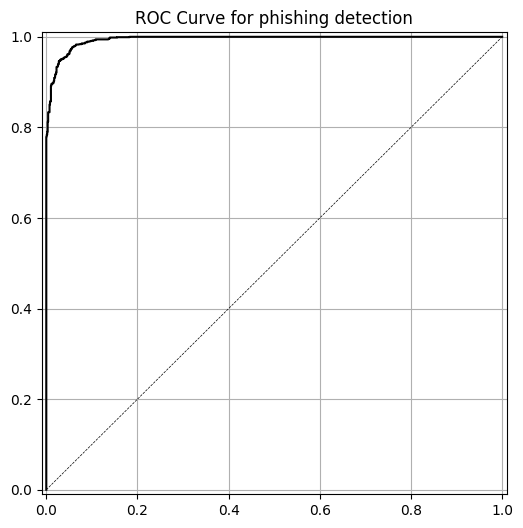

In [71]:
y_pred_prob_nn_1 = model_1.predict(X_val)
y_pred_class_nn_1 = (y_pred_prob_nn_1 > 0.5).astype(int)

print('accuracy is {:.3f}'.format(accuracy_score(y_val, y_pred_class_nn_1)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_val, y_pred_prob_nn_1)))

fpr, tpr, _ = roc_curve(y_val, y_pred_prob_nn_1)
_, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, 'k-')
ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)
ax.grid(True)
ax.set(title='ROC Curve for phishing detection',
        xlim=[-0.01, 1.01], ylim=[-0.01, 1.01]);

When we plot the loss over the training period, we can see that the model converges quite quickly and then slowly keeps improving. A slight improvement might be possible with longer training, but no large gains are expected.

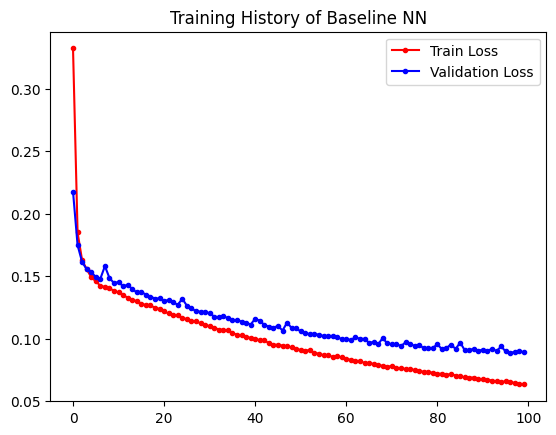

In [74]:
fig, ax = plt.subplots()
ax.plot(run_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Training History of Baseline NN")
ax.legend()

#### A second model architecture

Let's add another hidden layer and shift a bit with the layer sizes to see if we can get better performance.

Epoch 1/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8636 - loss: 0.3522 - val_accuracy: 0.9186 - val_loss: 0.2036
Epoch 2/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9293 - loss: 0.1743 - val_accuracy: 0.9281 - val_loss: 0.1657
Epoch 3/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9353 - loss: 0.1546 - val_accuracy: 0.9331 - val_loss: 0.1533
Epoch 4/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9382 - loss: 0.1483 - val_accuracy: 0.9380 - val_loss: 0.1475
Epoch 5/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9415 - loss: 0.1390 - val_accuracy: 0.9358 - val_loss: 0.1433
Epoch 6/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9418 - loss: 0.1357 - val_accuracy: 0.9362 - val_loss: 0.1410
Epoch 7/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9445 - loss: 0.1313 - val_accuracy: 0.9326 - val_loss: 0.1581
Epoch 8/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9465 - loss: 0.1295 - val_accu

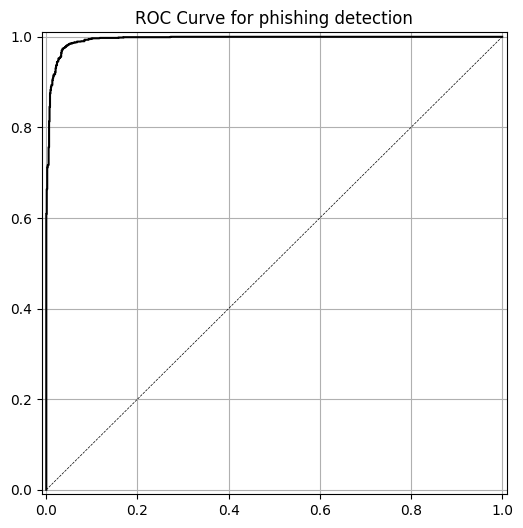

In [17]:
X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y_scaled)

INPUT_SIZE = X_one_hot.shape[1]
HIDDEN_SIZE_1 = INPUT_SIZE // 2
HIDDEN_SIZE_2 = HIDDEN_SIZE_1 // 2
OUTPUT_SIZE = 1
ACTIVATION_HIDDEN = 'tanh'
ACTIVATION_FINAL = 'sigmoid'
EPOCHS = 150

model_2 = Sequential()
model_2.add(Input((INPUT_SIZE, )))
model_2.add(Dense(HIDDEN_SIZE_1, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(HIDDEN_SIZE_2, activation=ACTIVATION_HIDDEN))
model_2.add(Dense(OUTPUT_SIZE, activation=ACTIVATION_FINAL))

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
run_hist_2 = model_2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=EPOCHS)

y_pred_prob_nn_2 = model_2.predict(X_val)
y_pred_class_nn_2 = (y_pred_prob_nn_2 > 0.5).astype(int)

print('accuracy is {:.3f}'.format(accuracy_score(y_val, y_pred_class_nn_2)))
print('roc-auc is {:.3f}'.format(roc_auc_score(y_val, y_pred_prob_nn_2)))

fpr, tpr, _ = roc_curve(y_val, y_pred_prob_nn_2)
_, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, 'k-')
ax.plot([0, 1], [0, 1], 'k--', linewidth=.5)
ax.grid(True)
ax.set(title='ROC Curve for phishing detection',
        xlim=[-0.01, 1.01], ylim=[-0.01, 1.01]);

In [77]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 23)             │         1,081 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,073 (15.91 KB)

 Trainable params: 1,357 (5.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,716 (10.61 KB)

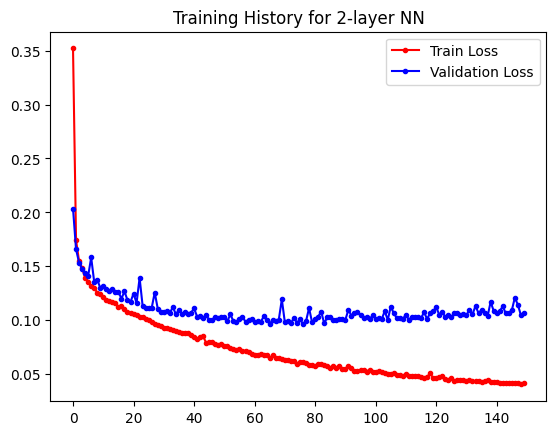

In [75]:
fig, ax = plt.subplots()
ax.plot(run_hist_2.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(run_hist_2.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Training History for 2-layer NN")
ax.legend()

Performance actually goes down and the loss starts diverging after 60-100 epochs. This is a sign of overfitting, which makes sense when adding additional layers on this relatively simple dataset.

## Autoencoder pretraining

The relatively naive way of performing PCA for dimensionality reduction seemed to not influence the preliminray baseline measurments. But since there is a reasonable amount of redundancy in the data (explain 95% with about 2/3 of the entire set), a more sophisticated method might work here. For this I chose to implement an autoencoder pretraining step, embedding the dataset into a lower dimension space.

First we build the autoencoder structure and train it in the adversarial setting. Then we rebuild a neural network and train it on the latent representation as supplied by the autoencoder.

For this we start by building "the simplest possible autoencoder", as defined in the [Keras documentation](https://blog.keras.io/building-autoencoders-in-keras.html). We'll also add the additional activity regularization to improve over the basic implementation.

In [81]:
from keras import Input, Model
from keras import regularizers

input_size = X_one_hot.shape[1]
hidden_dim = input_size // 2
latent_dim = 8

# Encoder
encoder_input_layer = Input(shape=(input_size, ))
encoder_hidden_layer = Dense(hidden_dim, activation='sigmoid', activity_regularizer=regularizers.l1(10e-5))(encoder_input_layer)
encoder_output_layer = Dense(latent_dim, activation='tanh')(encoder_hidden_layer)
encoder = Model(inputs=encoder_input_layer, outputs=encoder_output_layer)

# Decoder
decoder_input_layer = Input(shape=(latent_dim,))
decoder_hidden_layer = Dense(hidden_dim, activation="tanh")(decoder_input_layer)
decoder_output_layer = Dense(input_size, activation="sigmoid")(decoder_hidden_layer)
decoder = Model(inputs=decoder_input_layer, outputs=decoder_output_layer)

# Full Architecture
autoencoder_input = Input(shape=(input_size, ))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
ae_model = Model(inputs=autoencoder_input, outputs=decoded)

ae_model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 46)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_17 (Functional)      │ (None, 8)              │         1,273 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_18 (Functional)      │ (None, 46)             │         1,311 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,584 (10.09 KB)

 Trainable params: 2,584 (10.09 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
import tensorflow as tf

class ReconstructionAccuracy(tf.keras.metrics.Metric):
    def __init__(self, **kwargs):
        super().__init__(name='reconstruction_accuracy', **kwargs)
        self.total   = self.add_weight(name='total',   initializer='zeros')
        self.count   = self.add_weight(name='count',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        preds   = tf.cast(y_pred >= 0.5, tf.float32)
        correct = tf.cast(tf.equal(preds, tf.cast(y_true, tf.float32)), tf.float32)
        self.total.assign_add(tf.reduce_sum(correct))
        self.count.assign_add(tf.cast(tf.size(correct), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.)
        self.count.assign(0.)

ae_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[ReconstructionAccuracy()])
ae_hist_1 = ae_model.fit(X_train, X_train, epochs=400, batch_size=32, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5415 - reconstruction_accuracy: 0.7351 - val_loss: 0.4827 - val_reconstruction_accuracy: 0.7722
Epoch 2/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4447 - reconstruction_accuracy: 0.7949 - val_loss: 0.4154 - val_reconstruction_accuracy: 0.8078
Epoch 3/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3950 - reconstruction_accuracy: 0.8193 - val_loss: 0.3751 - val_reconstruction_accuracy: 0.8293
Epoch 4/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3590 - reconstruction_accuracy: 0.8414 - val_loss: 0.3431 - val_reconstruction_accuracy: 0.8508
Epoch 5/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3279 - reconstruction_accuracy: 0.8591 - val_loss: 0.3151 - val_reconstruction_accuracy: 0.8664
Epoch 6/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3054 - reconstruction_accuracy: 0.8694 - val_loss: 0.2985 - val_reconstruction_accuracy: 0.8720
Epoch 7/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

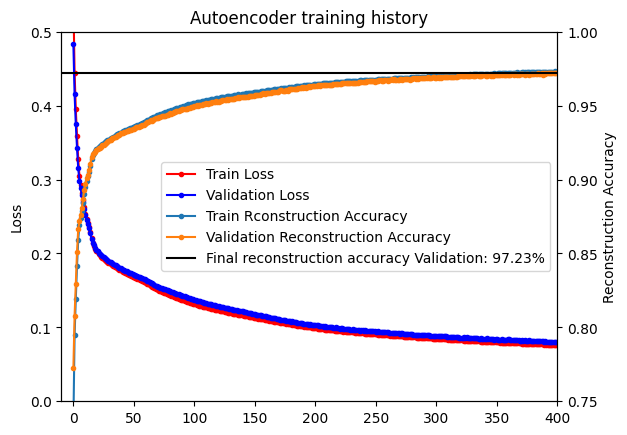

In [108]:
fig, ax = plt.subplots()
ax.plot(ae_hist_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(ae_hist_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_ylabel("Loss")
ax.set_ylim([0, 0.5])

ax_r = ax.twinx()
ax_r.plot(ae_hist_1.history['reconstruction_accuracy'], marker='.', label="Train Rconstruction Accuracy")
ax_r.plot(ae_hist_1.history['val_reconstruction_accuracy'], marker='.', label="Validation Reconstruction Accuracy")
ax_r.set_ylabel("Reconstruction Accuracy")
ax_r.set_ylim([0.75, 1])
final_reconstruction_acc_val = ae_hist_1.history['val_reconstruction_accuracy'][-1]
ax_r.plot(
    ax_r.get_xlim(), 
    [final_reconstruction_acc_val, final_reconstruction_acc_val],
    'k-',
    label=f"Final reconstruction accuracy Validation: {final_reconstruction_acc_val*100:.2f}%"
    )

ax.set_title("Autoencoder training history")
ax.set_xlim(-10, 400)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

Below we compare a tensor reconstructed by the model with the input tensor. We can see that a few values are wrongly reconstructed. 

In [109]:
test_input = X_train.iloc[0].to_numpy()
reconstructed = pd.DataFrame(
        decoder(
            encoder(test_input.reshape((1, -1)))
        ), 
        columns=X_train.columns
    ).map(lambda v: 1 if v >= 0.5 else 0)

reconstructed.to_numpy() == test_input

array([[ True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])

Next we can see if there are correlations in whether the same inputs are structurally wrongly reconstructed. This may indicate that these variables are of less importance for the variability of the data.

In [110]:
val_input = X_val.to_numpy().astype('float32')

reconstructed = decoder(encoder(tf.convert_to_tensor(val_input))).numpy()
reconstructed = (reconstructed >= 0.5).astype(int)

mismatches = pd.DataFrame(reconstructed != val_input, columns=X_val.columns).sum(axis=0)
mismatch_pct = (mismatches / X_val.shape[0] * 100).map(lambda v: f"{v:.2f}%").to_frame(name='mismatch_rate')
mismatch_pct

,mismatch_rate
having_ip_address,5.52%
shortining_service,2.13%
having_at_symbol,10.81%
double_slash_redirecting,2.04%
prefix_suffix,3.17%
domain_registration_length,5.16%
favicon,0.36%
port,1.58%
https_token,4.75%
request_url,5.61%


From this we can see that some features are hard to capture in the latent dimension, together with all the other features. A cutoff for this could be chosen very deliberately by experimentation, but due to the exploratory nature of this assignement, a rather arbitrary cutoff of 7% is chosen.

Later, we can exclude these columns from the dimensinoality reduction step when building the full model architecture. This way we don't lose valuable information due to the incompressibility of some features.

In [ ]:
MISMATCH_CUTOFF = 0.07
exclude_from_dim_red_cols = mismatch_pct[(mismatches/X_val.shape[0]) > MISMATCH_CUTOFF].index.to_list()
exclude_from_dim_red_cols

['having_at_symbol',
 'age_of_domain',
 'page_rank',
 'google_index',
 'statistical_report']

For many of these features they are strong predictors of phishing, so having them undistorted is important. For example, the dataset authors mention that over 95% of phishing sites have no Page Rank, therefore making it strongly imbalanced within the class. The autoencoder mastly learns to reconstruct the majority class in this case, leading to significant reconstruction error.

With that information ready, let's start with building a simple architecture on top of the autoencoder.

In [124]:
encoded_inputs = Input(shape=(latent_dim,))
x = Dense(4, activation='relu')(encoded_inputs)
output = Dense(1, activation='sigmoid')(x)
clf = Model(encoded_inputs, output)

clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_autoencoded = encoder.predict(X_train)
full_model_history_1 = clf.fit(X_autoencoded, y_train, epochs=50, batch_size=32, validation_data=(encoder.predict(X_test), y_test))

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.6092 - val_accuracy: 0.8318 - val_loss: 0.5572
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8610 - loss: 0.4856 - val_accuracy: 0.8716 - val_loss: 0.4348
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8860 - loss: 0.3769 - val_accuracy: 0.8801 - val_loss: 0.3538
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8889 - loss: 0.3163 - val_accuracy: 0.8797 - val_loss: 0.3134
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8919 - loss: 0.2870 - val_accuracy: 0.8838 - val_loss: 0.2931
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8954 - loss: 0.2722 - val_accuracy: 0.8856 - val_loss: 0.2826
Epoch 7/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8957 - loss: 0.2643 - val_accuracy: 0.8860 - val_loss: 0.2764
Epoch 8/50
208/208 ━━━

In [25]:
clf.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125 (504.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 84 (340.00 B)

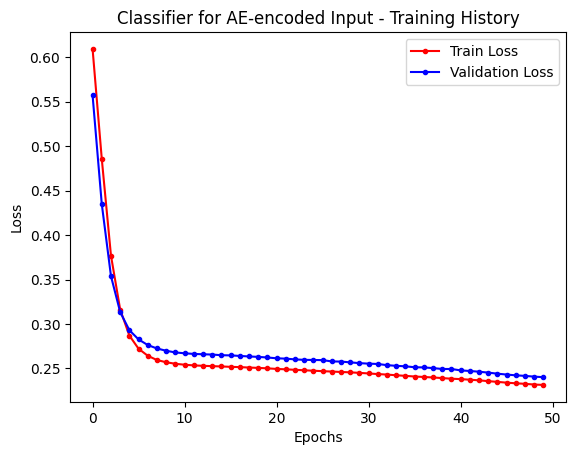

In [ ]:
fig, ax = plt.subplots()
ax.plot(full_model_history_1.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(full_model_history_1.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Classifier for AE-encoded Input - Training History")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")
ax.legend()

With this we can see that the performance takes a hit with ana ccuracy of 0.93, but the model itself only takes a quarter of the parameters of the previous model. This comes at the cost of having to train the autoencoder model, but the advantage is that this preprocessing layer can be reused, so repeat experiments are significantly faster. Especially when network size grows this can result in a very large improvement in iteration speed over hyperparameters.

### Interpretability

Especially with dimensionality reduction techniques and neural networks, interpretability is a major issue. Dimensionality reduction results in non-physical combinations of features that can be extremely hard to untangle, and the weights of Neural Networks are often not easily reducible to an understanding of the decision making process in the network. 

Luckily there are some techniques that make this more visible:
- Latent-space feature sensitivity
- Latent-space visualisation/clustering
- Saliency/Integrated Gradients
- Latent unit activation statistics
- End-to-end saliency

#### Latent sensitivity

We'll start with latent variable sensitivity, thi is a measure of how sensitive the latent space representation is to perturbations of an input variable.

In [128]:
def latent_sensitivity(encoder, X, feature_index):
    X_copy = X.copy()
    X_copy.iloc[:, feature_index] = 1 - X_copy.iloc[:, feature_index]  # flip bit
    original = encoder.predict(X)
    perturbed = encoder.predict(X_copy)
    return np.mean(np.abs(perturbed - original), axis=0)

sensitivity_data = {}
for i, feature in enumerate(X_scaled.columns):
    sensitivity_data[feature] = latent_sensitivity(encoder, X_one_hot, i)

sensitivity_df = pd.DataFrame(sensitivity_data)

346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step
346/346 ━━━━━━━━━━━━━━━━━━━━ 

Text(0.5, 1.0, 'Heatmap for latent space sensitivity')

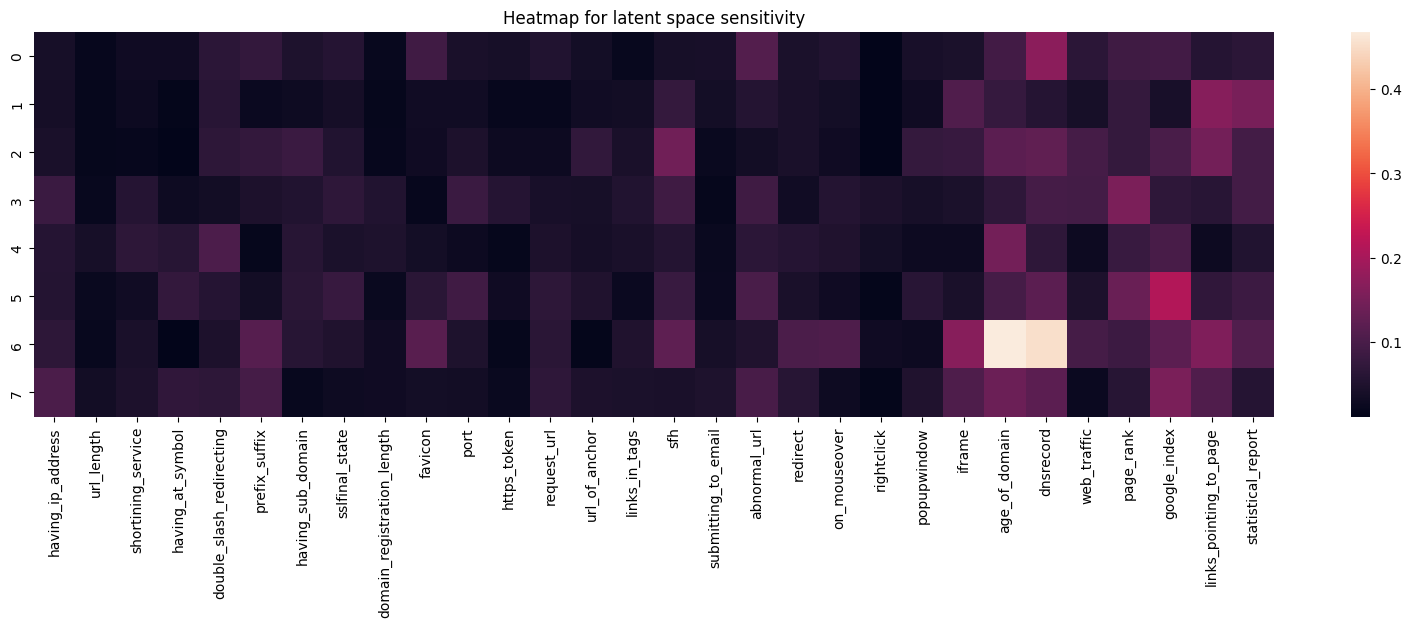

In [129]:
plt.figure(figsize=(20, 5))
sns.heatmap(sensitivity_df)
plt.title("Heatmap for latent space sensitivity")

From this we can see that TODO

### Latent space visualisation

Ther are multiple methods of visualising the latent space. Here we compare a linear and a non-linear method. We'll also use clustering to see if the latent space has learned to represent phishing and non-phishing sites with similar encodings.

First we need to get the latent representation for each of the input samples

In [130]:
X_encoded = encoder(X_one_hot)
X_encoded.shape

TensorShape([11055, 8])

Then we'll use linear PCA to project the latent space onto a 2-dimensional subspace. Here we can see that the low dimensional subspace clearly distinguishes between the two input classes.

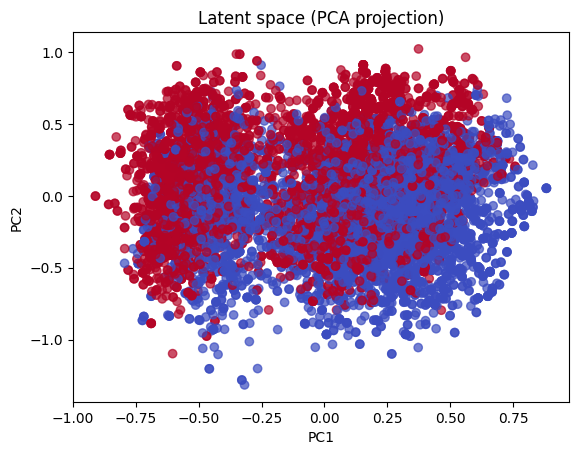

In [131]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
plt.title("Latent space (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2");

We can also try this with a non-linear method like t-SNE for high-dimensional data visualisation.

In [137]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_encoded)
X_tsne

array([[-23.862663 ,   4.207999 ],
       [-45.870888 ,  21.91636  ],
       [-42.509537 ,  -5.750468 ],
       ...,
       [ 29.361513 , -52.62383  ],
       [ -3.5035918,  45.828003 ],
       [ 33.555508 ,  16.474503 ]], shape=(11055, 2), dtype=float32)

Text(0.5, 1.0, 'Latent space (t-SNE projection)')

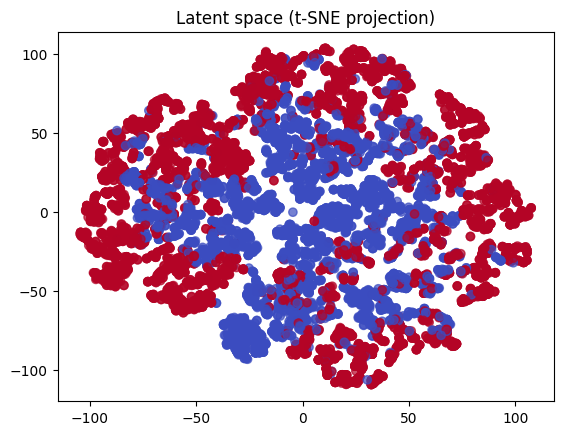

In [138]:
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
plt.title("Latent space (t-SNE projection)")

[UMAP](https://umap-learn.readthedocs.io/en/latest/) is another powerful dimensionality reduction method that generally performs better than t-SNE on highly nonlinear data. However, when the data is actually relatively linearly separable, the solver can have trouble with properly converging.

In [139]:
import umap

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_encoded)

c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\um

Text(0.5, 1.0, 'Latent space (UMAP projection)')

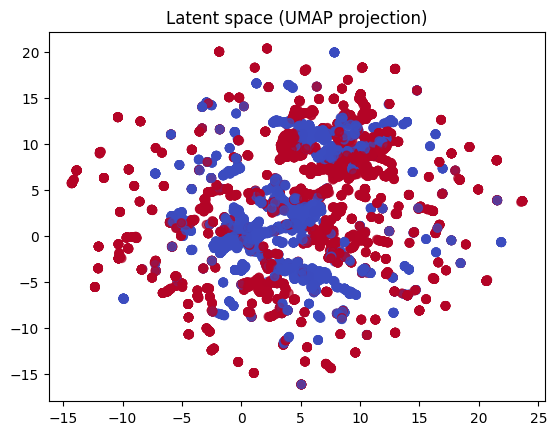

In [140]:
plt.scatter(X_umap[:,0], X_umap[:,1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
plt.title("Latent space (UMAP projection)")

### Bringing it all together

346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


c:\Users\flori\AppData\Local\pypoetry\Cache\virtualenvs\ibm-ml-osM9NXud-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


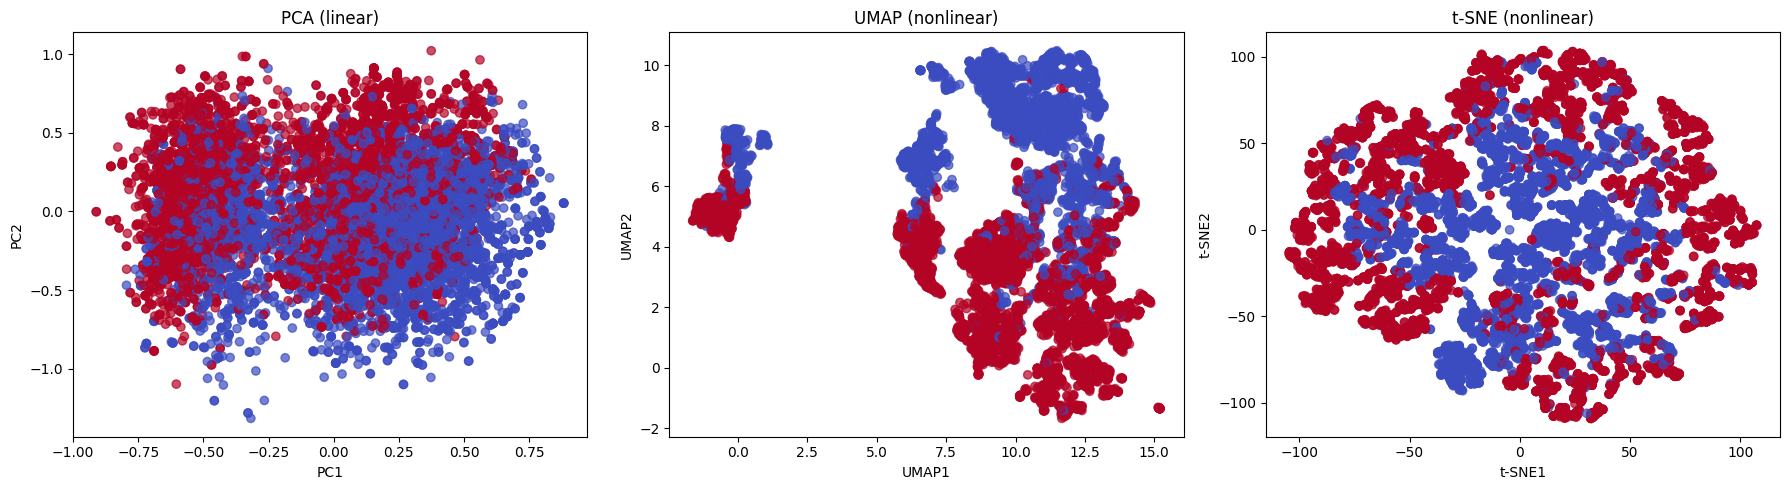

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# ---- 1. Encode data ----
X_encoded = encoder.predict(X_one_hot)

# ---- 2. PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

# ---- 3. UMAP ----
# Add noise to help the eigensolver initialise better
X_noisy = X_one_hot + 0.01 * np.random.randn(*X_one_hot.shape)
# Forcing the number of neighbors helps with a simple manifold
umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.1)
X_umap = umap_model.fit_transform(X_noisy)

# ---- 4. t-SNE ----
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_encoded)

# ---- 5. Plot all three ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[0].set_title("PCA (linear)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# UMAP
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[1].set_title("UMAP (nonlinear)")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

# t-SNE
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_scaled.to_numpy(), cmap='coolwarm', alpha=0.7)
axes[2].set_title("t-SNE (nonlinear)")
axes[2].set_xlabel("t-SNE1")
axes[2].set_ylabel("t-SNE2")

plt.tight_layout()
plt.show()

PCA already produced clear linear separation between phishing and legitimate samples, indicating that the autoencoder learned a representation with predominantly linear structure. UMAP struggled due to a small eigengap in the spectral initialization step, which is consistent with a low‑curvature latent manifold. This suggests that the learned representation is simple and linearly organized, which is beneficial for interpretability.

## Latent unit activation statistics

Latent unit activation statistics measure how active each of the latent dimensions are for each of the input classes and how those distributions relate to each other. This analysis gives insight in what the latent dimensions mean and whether they encode general information, specific higher-level concepts or combinations directly related to the output classes.



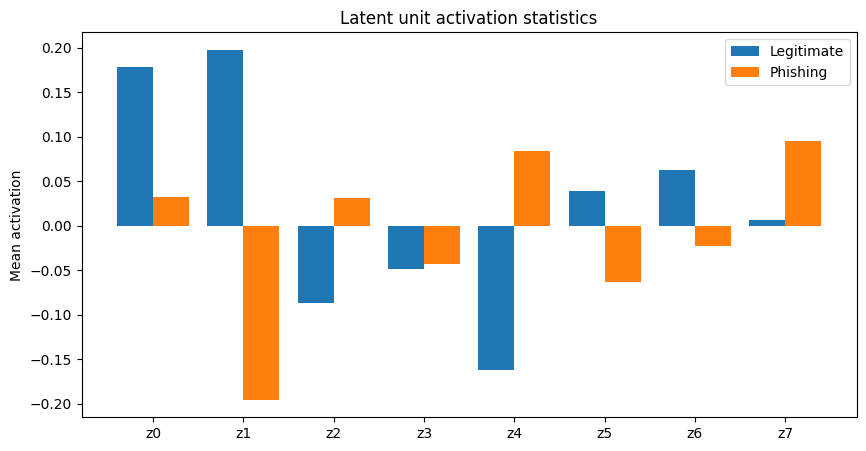

In [161]:
X_encoded = encoder(X_one_hot).numpy()

X_phish = X_encoded[(y_scaled == 1).to_numpy().reshape(-1)]
X_legit = X_encoded[(y_scaled == 0).to_numpy().reshape(-1)]

mean_phish = np.mean(X_phish, axis=0)
mean_legit = np.mean(X_legit, axis=0)

std_phish = np.std(X_phish, axis=0)
std_legit = np.std(X_legit, axis=0)

diff = mean_phish - mean_legit

units = np.arange(X_encoded.shape[1])

plt.figure(figsize=(10,5))
plt.bar(units - 0.2, mean_legit, width=0.4, label='Legitimate')
plt.bar(units + 0.2, mean_phish, width=0.4, label='Phishing')
plt.xticks(units, [f"z{i}" for i in units])
plt.ylabel("Mean activation")
plt.title("Latent unit activation statistics")
plt.legend()
plt.show()


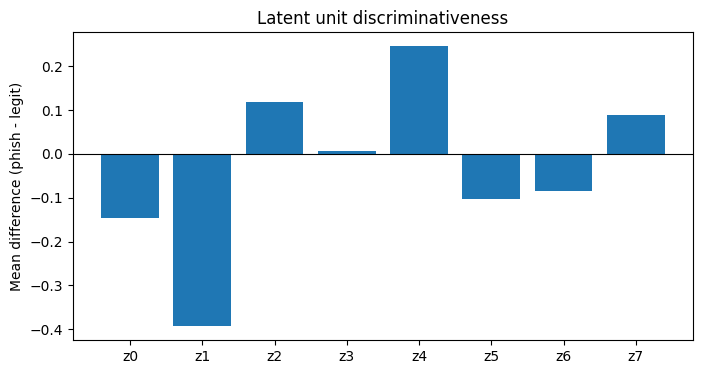

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(units, (diff))
plt.xticks(units, [f"z{i}" for i in units])
plt.ylabel("Mean difference (phish - legit)")
plt.title("Latent unit discriminativeness")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [165]:
from scipy.stats import ttest_ind

for i in range(X_encoded.shape[1]):
    t, p = ttest_ind(X_phish[:, i], X_legit[:, i])
    print(f"z{i}: p={p:.4f}")

z0: p=0.0000
z1: p=0.0000
z2: p=0.0000
z3: p=0.3024
z4: p=0.0000
z5: p=0.0000
z6: p=0.0000
z7: p=0.0000


From this analysis we can see that the discriminative power of the latent space representation is very good. Just one dimension does not provide significant discrimination between classes. This suggests that the autoencoder actually learns a meaningful distinction between phishing and non phishing sites. Some latent dimensions seem to encode specifically for a class (where one of the responses is large and the other small) and some seem ot encode for differences between classes (where both responses are opposite and similarly sized). For example, dimension z_0 encodes for legitimate sites while dimension z_7 encodes for phishing sites. Dimension z_1 encodes strongly for a difference between phishing- and non-phishing sites.

Having a single dimension that provides no meaningful distinction might indicate that the size of the latent space is slightly to large. Possibly, a latent dimension of size 7 could also suffice with wimilar performance. However, this is also greatly dependent on the autoencoder hyperparameters and overall structure. 

## Perfecting the model

The autoencoder stage has given us a strong basis for building a coherent feature set. Some features were hard to capture in the latent space, but are very important for properly classifying phishing. Therefore a hybrid architecture was chosen where these features were not used in the dimensionality reduction autoencoder, but appended separately afterwards.

In [204]:
# Split data in test/train sets
X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y_scaled)

# Separate Dataset into sections to encode and sections to append later
X_train_to_encode = X_train.drop(columns=exclude_from_dim_red_cols)
X_test_to_encode = X_test.drop(columns=exclude_from_dim_red_cols)
X_val_to_encode = X_val.drop(columns=exclude_from_dim_red_cols)

X_train_excluded_from_encoding = X_train[exclude_from_dim_red_cols]
X_test_excluded_from_encoding = X_test[exclude_from_dim_red_cols]
X_val_excluded_from_encoding = X_val[exclude_from_dim_red_cols]

# Build autoencoder
ENCODER_INPUT_SIZE = X_train_to_encode.shape[1]
ENCODER_HIDDEN_DIM = input_size // 2
ENCODER_LATENT_DIM = 7

# Encoder
encoder_input_layer = Input(shape=(ENCODER_INPUT_SIZE, ))
encoder_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation='sigmoid', activity_regularizer=regularizers.l1(10e-5))(encoder_input_layer)
encoder_output_layer = Dense(ENCODER_LATENT_DIM, activation='tanh')(encoder_hidden_layer)
encoder = Model(inputs=encoder_input_layer, outputs=encoder_output_layer)

# Decoder
decoder_input_layer = Input(shape=(ENCODER_LATENT_DIM,))
decoder_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation="tanh")(decoder_input_layer)
decoder_output_layer = Dense(ENCODER_INPUT_SIZE, activation="sigmoid")(decoder_hidden_layer)
decoder = Model(inputs=decoder_input_layer, outputs=decoder_output_layer)

# Full Architecture
autoencoder_input = Input(shape=(ENCODER_INPUT_SIZE, ))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
ae_model = Model(inputs=autoencoder_input, outputs=decoded)

ae_model.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)     │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_36 (Functional)      │ (None, 7)              │           987 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_37 (Functional)      │ (None, 41)             │         1,021 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008 (7.84 KB)

 Trainable params: 2,008 (7.84 KB)

 Non-trainable params: 0 (0.00 B)

In [191]:
CLASSIFIER_INPUT_SIZE = ENCODER_LATENT_DIM + len(exclude_from_dim_red_cols)
CLASSIFIER_HIDDEN_SIZE = CLASSIFIER_INPUT_SIZE // 2
CLASSIFIER_OUTPUT_SIZE = 1

# Building the classifier
classifier_input_layer = Input(shape=(CLASSIFIER_INPUT_SIZE,))
classifier_hidden_layer = Dense(CLASSIFIER_HIDDEN_SIZE, activation='relu')(classifier_input_layer)
classifier_output_layer = Dense(CLASSIFIER_OUTPUT_SIZE, activation='sigmoid')(classifier_hidden_layer)
classifier_model = Model(classifier_input_layer, classifier_output_layer)

classifier_model.summary()

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85 (340.00 B)

 Trainable params: 85 (340.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile autoencoder
ae_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[ReconstructionAccuracy()])
encoder.trainable = True

# Train the Autoencoder
ae_final_hist = ae_model.fit(
    X_train_to_encode, 
    X_train_to_encode, 
    epochs=400, 
    batch_size=32, 
    shuffle=True, 
    validation_data=(X_test_to_encode, X_test_to_encode)
)

Epoch 1/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5463 - reconstruction_accuracy: 0.7409 - val_loss: 0.4966 - val_reconstruction_accuracy: 0.7695
Epoch 2/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4638 - reconstruction_accuracy: 0.7833 - val_loss: 0.4209 - val_reconstruction_accuracy: 0.8017
Epoch 3/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3912 - reconstruction_accuracy: 0.8210 - val_loss: 0.3663 - val_reconstruction_accuracy: 0.8390
Epoch 4/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3464 - reconstruction_accuracy: 0.8510 - val_loss: 0.3288 - val_reconstruction_accuracy: 0.8609
Epoch 5/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3162 - reconstruction_accuracy: 0.8654 - val_loss: 0.3062 - val_reconstruction_accuracy: 0.8704
Epoch 6/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2980 - reconstruction_accuracy: 0.8729 - val_loss: 0.2922 - val_reconstruction_accuracy: 0.8770
Epoch 7/400
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

In [210]:
# Compile classifier
classifier_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
classifier_model.trainable = True

# Build combined dataset
X_clf_train = np.concatenate(
    [
        encoder.predict(X_train_to_encode), 
        X_train_excluded_from_encoding.to_numpy()
    ], 
    axis=1
)
X_clf_test = np.concatenate(
    [
        encoder.predict(X_test_to_encode), 
        X_test_excluded_from_encoding.to_numpy()
    ], 
    axis=1
)
X_clf_val = np.concatenate(
    [
        encoder.predict(X_val_to_encode), 
        X_val_excluded_from_encoding.to_numpy()
    ], 
    axis=1
)

classifier_final_hist = classifier_model.fit(
    X_clf_train, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_clf_test, y_test)
)

208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Epoch 1/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6392 - loss: 1.3578 - val_accuracy: 0.6694 - val_loss: 1.0692
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6971 - loss: 0.8671 - val_accuracy: 0.7092 - val_loss: 0.7482
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7454 - loss: 0.6461 - val_accuracy: 0.7553 - val_loss: 0.5921
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7767 - loss: 0.5307 - val_accuracy: 0.7865 - val_loss: 0.5038
Epoch 5/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8011 - loss: 0.4615 - val_accuracy: 0.8141 - val_loss: 0.4464
Epoch 6/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8262 - loss: 0.4143 - val_accuracy: 0.8295 - val_loss: 0.4060
Epoch 7/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8425 - loss: 0.3799 - val_accuracy: 0.8444 - 

### History and Metrics

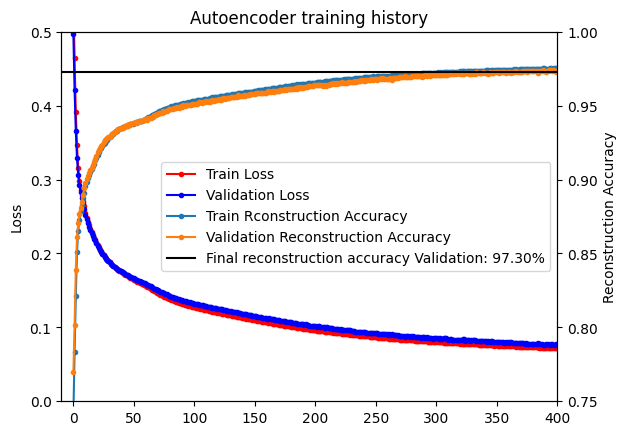

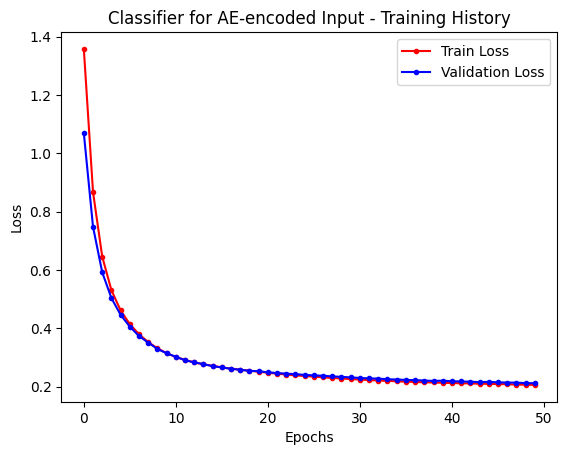

In [211]:
fig, ax = plt.subplots()
ax.plot(ae_final_hist.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(ae_final_hist.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_ylabel("Loss")
ax.set_ylim([0, 0.5])

ax_r = ax.twinx()
ax_r.plot(ae_final_hist.history['reconstruction_accuracy'], marker='.', label="Train Rconstruction Accuracy")
ax_r.plot(ae_final_hist.history['val_reconstruction_accuracy'], marker='.', label="Validation Reconstruction Accuracy")
ax_r.set_ylabel("Reconstruction Accuracy")
ax_r.set_ylim([0.75, 1])
final_reconstruction_acc_val = ae_final_hist.history['val_reconstruction_accuracy'][-1]
ax_r.plot(
    ax_r.get_xlim(), 
    [final_reconstruction_acc_val, final_reconstruction_acc_val],
    'k-',
    label=f"Final reconstruction accuracy Validation: {final_reconstruction_acc_val*100:.2f}%"
    )

ax.set_title("Autoencoder training history")
ax.set_xlim(-10, 400)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig, ax = plt.subplots()
ax.plot(classifier_final_hist.history["loss"],'r', marker='.', label="Train Loss")
ax.plot(classifier_final_hist.history["val_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Classifier for AE-encoded Input - Training History")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")
ax.legend()

### Combining the architecture into a single callable

With the separate parts of the model trained, we ca now combine them into a single callable to run the entire chain in one go.

In [ ]:
from tensorflow.keras.layers import Input, Lambda, Concatenate
from tensorflow.keras.models import Model
import tensorflow as tf

ENC_SIZE = ENCODER_INPUT_SIZE
BYPASS_SIZE = len(exclude_from_dim_red_cols)
FULL_INPUT_SIZE = ENC_SIZE + BYPASS_SIZE

# To select the correct columns in the model we need to convert them to indices
ALL_COLUMNS = X_one_hot.columns
BYPASS_COLS = exclude_from_dim_red_cols
ENCODE_COLS = [c for c in ALL_COLUMNS if c not in BYPASS_COLS]
ENCODE_IDX = [ALL_COLUMNS.get_loc(c) for c in ENCODE_COLS]
BYPASS_IDX = [ALL_COLUMNS.get_loc(c) for c in BYPASS_COLS]

full_input = Input(shape=(FULL_INPUT_SIZE,))
encoded_part = Lambda(lambda x: tf.gather(x, ENCODE_IDX, axis=1), output_shape=(ENC_SIZE,))(full_input)
bypass_part  = Lambda(lambda x: tf.gather(x, BYPASS_IDX, axis=1), output_shape=(BYPASS_SIZE,))(full_input)
latent = encoder(encoded_part)
classifier_input = Concatenate()([latent, bypass_part])
classifier_output = classifier_model(classifier_input)
full_model = Model(inputs=full_input, outputs=classifier_output)

encoder.trainable = False
classifier_model.trainable = False

preds = full_model.predict(X_one_hot)

346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [213]:
from sklearn.metrics import classification_report

print(classification_report(y_scaled, [0 if pred < 0.5 else 1 for pred in preds]))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      4898
           1       0.91      0.94      0.92      6157

    accuracy                           0.91     11055
   macro avg       0.91      0.91      0.91     11055
weighted avg       0.91      0.91      0.91     11055



### Single Architecture

It is also possible to build the entire architecture from the start. This way the entire model can be trained together.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Lambda, Concatenate
from keras.utils import plot_model
from keras import Input, Model, regularizers

In [ ]:
class ReconstructionAccuracy(tf.keras.metrics.Metric):

    def __init__(self, **kwargs):
        super().__init__(name='reconstruction_accuracy', **kwargs)
        self.total   = self.add_weight(name='total',   initializer='zeros')
        self.count   = self.add_weight(name='count',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        preds   = tf.cast(y_pred >= 0.5, tf.float32)
        correct = tf.cast(tf.equal(preds, tf.cast(y_true, tf.float32)), tf.float32)
        self.total.assign_add(tf.reduce_sum(correct))
        self.count.assign_add(tf.cast(tf.size(correct), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.)
        self.count.assign(0.)

def split_data(X, y, rs=42, tt_split=0.6, tv_split=0.5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=tt_split, random_state=rs, stratify=y)
    X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=tv_split, random_state=rs, stratify=y_test)
    return X_train, X_test, X_val, y_train, y_test, y_val

phishing_websites = fetch_ucirepo(id=327)
X = phishing_websites.data.features
y = phishing_websites.data.targets

binary_columns = X.columns[X.nunique() == 2]
ternary_columns = X.columns.drop(binary_columns)
X_scaled = X.copy()
X_scaled[binary_columns] = (X_scaled[binary_columns] + 1) // 2
X_scaled[ternary_columns] = X_scaled[ternary_columns] + 1
oh_encode = OneHotEncoder(
    sparse_output=False
)
oh_encoded = oh_encode.fit_transform(X_scaled[ternary_columns])
oh_encoded_df = pd.DataFrame(
    oh_encoded,
    columns=encoder.get_feature_names_out(),
    dtype=int
)
X_one_hot = pd.concat([X_scaled[binary_columns], oh_encoded_df], axis=1) 
y_scaled = y.copy()
y_scaled.loc[y_scaled['result'] == -1, 'result'] = 0

In [ ]:
encode_cols = [c for c in X_one_hot.columns if c not in exclude_from_dim_red_cols]
bypass_cols = exclude_from_dim_red_cols

encode_idx = [X_one_hot.columns.get_loc(c) for c in encode_cols]
bypass_idx = [X_one_hot.columns.get_loc(c) for c in bypass_cols]

FULL_INPUT_SIZE = len(X_one_hot.columns)

## Model Input Layer
full_input = Input(shape=(FULL_INPUT_SIZE,), name="dataframe_input")

## Separate Data To Encode
encoded_part = Lambda(
    lambda x: tf.gather(x, encode_idx, axis=1),
    name="encoded_feature_slice"
)(full_input)

## Separate Data For Bypass
bypass_part = Lambda(
    lambda x: tf.gather(x, bypass_idx, axis=1),
    name="bypass_feature_slice"
)(full_input)

## Autoencoder Hyperparameters
ENCODER_INPUT_SIZE = len(encode_cols)
ENCODER_HIDDEN_DIM = ENCODER_INPUT_SIZE // 2
ENCODER_LATENT_DIM = 7

## Build Encoder
enc_input_layer = Input(shape=(ENCODER_INPUT_SIZE, ), name='encoder_input')
enc_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation='sigmoid', activity_regularizer=regularizers.l1(10e-5), name="encoder_dense")(enc_input_layer)
enc_output_layer = Dense(ENCODER_LATENT_DIM, activation='tanh', name='latent_output')(enc_hidden_layer)
enc = Model(inputs=enc_input_layer, outputs=enc_output_layer, name="Encoder")

## Build Decoder
dec_input_layer = Input(shape=(ENCODER_LATENT_DIM,), name='decoder_input')
dec_hidden_layer = Dense(ENCODER_HIDDEN_DIM, activation="tanh", name='decoder_dense')(dec_input_layer)
dec_output_layer = Dense(ENCODER_INPUT_SIZE, activation="sigmoid", name='reconstruction')(dec_hidden_layer)
dec = Model(inputs=dec_input_layer, outputs=dec_output_layer, name="Decoder")

## Set Up Encoder Structure
latent = enc(encoded_part)
reconstruction = dec(latent)

## Build Input Connection To Classifier
cls_input = Concatenate(name="classifier_concat")([latent, bypass_part])

## Classifier Hyperparameters
CLASSIFIER_INPUT_SIZE = ENCODER_LATENT_DIM + len(bypass_cols)
CLASSIFIER_HIDDEN_SIZE = CLASSIFIER_INPUT_SIZE // 2
CLASSIFIER_OUTPUT_SIZE = 1

## Building the classifier
cls_input_layer = Input(shape=(CLASSIFIER_INPUT_SIZE,), name='classifier_input')
cls_hidden_layer = Dense(CLASSIFIER_HIDDEN_SIZE, activation='relu', name='classifier_dense')(cls_input_layer)
cls_output_layer = Dense(CLASSIFIER_OUTPUT_SIZE, activation='sigmoid', name="prediction")(cls_hidden_layer)
cls_model = Model(cls_input_layer, cls_output_layer, name="Classifier")

## Make Classifier Connections
prediction = cls_model(cls_input)

## Build Complete Model
full_multi_output_model = Model(
    inputs=full_input,
    outputs=[reconstruction, prediction],
    name="autoencoder_classifier_joint_model"
)

plot_model(
    full_multi_output_model,
    to_file="./images/full_model_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=200
)

full_multi_output_model.summary()

Model: "autoencoder_classifier_joint_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dataframe_input     │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoded_feature_sl… │ (None, 41)        │          0 │ dataframe_input[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 7)         │        987 │ encoded_feature_… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bypass_feature_sli… │ (None, 5)         │          0 │ dataframe_input[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_concat   │ (None, 12)        │          0 │ Encoder[0][0],    │
│ (Concatenate)       │                   │            │ bypass_feature_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder             │ (None, 41)        │      1,021 │ Encoder[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classifier          │ (None, 1)         │         85 │ classifier_conca… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,093 (8.18 KB)

 Trainable params: 2,093 (8.18 KB)

 Non-trainable params: 0 (0.00 B)

In [266]:
X_train, X_test, X_val, y_train, y_test, y_val = split_data(X_one_hot, y_scaled)

full_multi_output_model.compile(
    optimizer="adam",
    loss={
        "Decoder": "mse",
        "Classifier": "binary_crossentropy" 
    },
    metrics={
        "Decoder": ReconstructionAccuracy(),
        "Classifier": []
    },
    loss_weights={
        "Decoder": 1.0,
        "Classifier": 1.0
    }
)

multi_model_history = full_multi_output_model.fit(
    X_train,
    {
        "Decoder": X_train.iloc[:, encode_idx], 
        "Classifier": y_train
    },
    epochs=200,
    batch_size=32,
    validation_data=(
        X_test, 
        {
            "Decoder": X_test.iloc[:, encode_idx], 
            "Classifier": y_test
        }
    )
)

Epoch 1/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Classifier_loss: 0.6685 - Decoder_loss: 0.1855 - Decoder_reconstruction_accuracy: 0.5051 - loss: 0.8557 - val_Classifier_loss: 0.5428 - val_Decoder_loss: 0.1617 - val_Decoder_reconstruction_accuracy: 0.5246 - val_loss: 0.7054
Epoch 2/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Classifier_loss: 0.3413 - Decoder_loss: 0.1520 - Decoder_reconstruction_accuracy: 0.5247 - loss: 0.4948 - val_Classifier_loss: 0.2082 - val_Decoder_loss: 0.1471 - val_Decoder_reconstruction_accuracy: 0.5101 - val_loss: 0.3562
Epoch 3/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Classifier_loss: 0.1795 - Decoder_loss: 0.1437 - Decoder_reconstruction_accuracy: 0.5098 - loss: 0.3245 - val_Classifier_loss: 0.1795 - val_Decoder_loss: 0.1430 - val_Decoder_reconstruction_accuracy: 0.5188 - val_loss: 0.3201
Epoch 4/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Classifier_loss: 0.1621 - Decoder_loss: 0.1395 - Decoder_reconstruction_accuracy: 0.5164 - loss: 0.302

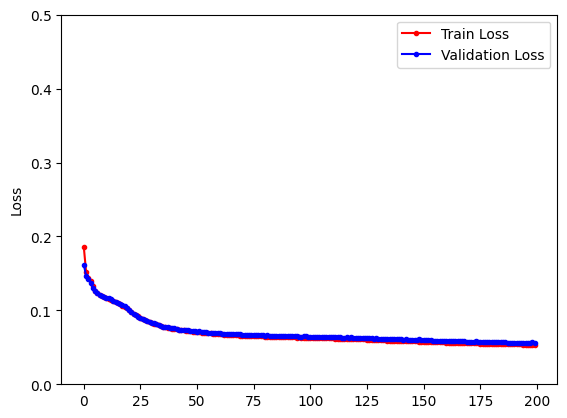

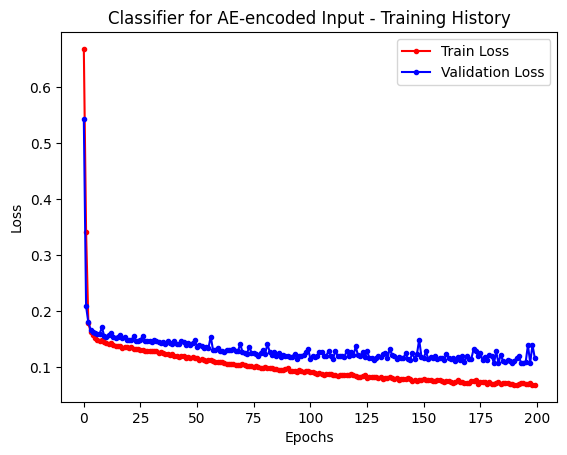

In [268]:
fig, ax = plt.subplots()
ax.plot(multi_model_history.history["Decoder_loss"],'r', marker='.', label="Train Loss")
ax.plot(multi_model_history.history["val_Decoder_loss"],'b', marker='.', label="Validation Loss")
ax.set_ylabel("Loss")
ax.set_ylim([0, 0.5])

ax.legend()

# ax_r = ax.twinx()
# ax_r.plot(multi_model_history.history['Decoder_reconstruction_accuracy'], marker='.', label="Train Rconstruction Accuracy")
# ax_r.plot(multi_model_history.history['val_Decoder_reconstruction_accuracy'], marker='.', label="Validation Reconstruction Accuracy")
# ax_r.set_ylabel("Reconstruction Accuracy")
# #ax_r.set_ylim([0.75, 1])
# final_reconstruction_acc_val = multi_model_history.history['val_Decoder_reconstruction_accuracy'][-1]
# ax_r.plot(
#     ax_r.get_xlim(), 
#     [final_reconstruction_acc_val, final_reconstruction_acc_val],
#     'k-',
#     label=f"Final reconstruction accuracy Validation: {final_reconstruction_acc_val*100:.2f}%"
#     )

# ax.set_title("Autoencoder training history")
# ax.set_xlim(-10, 400)

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax_r.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

fig, ax = plt.subplots()
ax.plot(multi_model_history.history["Classifier_loss"],'r', marker='.', label="Train Loss")
ax.plot(multi_model_history.history["val_Classifier_loss"],'b', marker='.', label="Validation Loss")
ax.set_title("Classifier for AE-encoded Input - Training History")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")
ax.legend()